<a href="https://colab.research.google.com/github/ahcamachod/clusterizacion-de-datos-segmentacion-de-clientes/blob/main/segmentos_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clusterización de Datos: Segmentación de clientes

En este notebook estaremos desarrollando un análisis completo de Ciencia de Datos con Machine Learning para la segmentación de clientes.

De manera puntual, emplearemos una técnica de segmentación del comportamiento del cliente basada en datos conocida como RFM (Recencia o Actualidad, Frecuencia, y Valor Monetario).

El dataset utilizado fue adaptado para nuestro entrenamiento, tomando como referencia un dataset de Kaggle llamado **Brazilian E-Commerce Public Dataset by Olist**.

*dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce*

## Aula 1

### 1.2 Importando y explorando el dataset

In [1]:
# modulos y librerias
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# conectar google drive con colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# cargar datos en un DataFrame
URI = '/content/drive/MyDrive/Data_Science/Bootcamp Data Science/Machine Learning - Bootcamp DS3/Clusterización de datos: segmentación de clientes/e_commerce.csv'
df = pd.read_csv(URI)

In [4]:
# informacion genarl del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116581 entries, 0 to 116580
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   muestra            116581 non-null  int64  
 1   id_cliente         116581 non-null  object 
 2   id_unico_cliente   116581 non-null  object 
 3   item_id            116581 non-null  int64  
 4   cp_cliente         116581 non-null  int64  
 5   ciudad_cliente     116581 non-null  object 
 6   estado_cliente     116581 non-null  object 
 7   id_pedido          116581 non-null  object 
 8   status_pedido      116581 non-null  object 
 9   horario_pedido     116581 non-null  object 
 10  pedido_aprobado    116567 non-null  object 
 11  pedido_entregador  115368 non-null  object 
 12  pedido_entregado   114066 non-null  object 
 13  fecha_estimada     116581 non-null  object 
 14  id_vendedor        116581 non-null  object 
 15  precio             116581 non-null  float64
 16  pr

### 1.2.1 Columnas y Descripción

**muestra**: Numeración creciente de los datos.

**id_cliente**: Número de identificación del cliente que realiza la compra.

**id_unico_cliente**: Número único para cada cliente en función de su dirección IP, independiente de la compra.

**item_id**: Número de identificación del item comprado.

**cp_cliente**: Código postal del cliente.

**ciudad_cliente**: Ciudad donde se realizó el pedido.

**estado_cliente**: Estado donde se realizó el pedido.

**id_pedido**: Número de identificación de la compra.

**status_pedido**: Status del pedido (Ej. Entregado, facturado, procesando, etc).

**horario_pedido**: Fecha y hora en la cual se realizó el pedido.

**pedido_aprobado**: Fecha y hora en la cual se aprobó el pedido.  
**pedido_entregador**: Fecha y hora en la cual se hizo entrega del pedido a la empresa transportadora.  

**pedido_entregado**:Fecha y hora en la cual se hizo entrega del pedido al cliente.

**fecha_estimada**:Fecha y hora estimada de entrega.

**id_vendedor**: Número de identificación del vendedor.

**precio**: Precio del producto.

**precio_envio**: Precio del envío.

**pago_secuencial**: Compra en la cual el cliente solicita más de una forma de pago (Ej. Crédito y débito, etc).

**pago_tipo**: Método de pago (Ej. factura, débito, voucher).

**pago_cuotas**: Número de cuotas escogido por el cliente para realizar el pago.

**pago_valor**: Valor total pago.

**review**: Nota que el consumidor da a todo el proceso.

**categoria**: Categoría del item comprado.

**cp_vendedor**: Código postal del vendedor.

**ciudad_vendedor**: Ciudad del vendedor.

**estado_vendedor**: Estado del vendedor.

In [5]:
# mostar 5 datos random del df
df.sample(5)

,muestra,id_cliente,id_unico_cliente,item_id,cp_cliente,ciudad_cliente,estado_cliente,id_pedido,status_pedido,horario_pedido,...,precio_envio,pago_secuencial,pago_tipo,pago_cuotas,pago_valor,review,categoria,cp_vendedor,ciudad_vendedor,estado_vendedor
80569,80569,d1739c719a801a392578b4a8e7902837,6d65796582835e3fcc5fcdae4c8e17f7,1,37590,cali,VAC,4adf69cec5c1814bd171dafc4c12ba73,entregado,2017-10-02 10:35:14,...,15.10,1,credito,3,35.04,5,telefonia,4160,bogota,DC
18511,18511,e8d796c25778bdcfe7e82a408b7d50da,9328041b31be172969af6b4ad2289bd7,1,13024,bogota,DC,9c3d371454ceddff5d8fa8aa86ac7c1e,entregado,2017-04-19 17:50:59,...,15.50,1,credito,8,714.50,1,papeleria,5729,bogota,DC
11368,11368,51775bbd39b922160a84caa55f2190c6,5038908495a860fe8f2dddc9ea5f7252,1,22071,medellin,ANT,ecbc00952c2d863b377c63a529282c5e,entregado,2018-04-13 17:51:37,...,26.98,1,credito,1,155.98,5,utilidades_domesticas,37443,pereira,RIS
21770,21770,09eefd631794ec720959fec7a3693db8,41754bce43d7d9a4398d70756d801e0f,1,55014,yopal,CAS,3235a845429a20753974e4bd70773c6f,entregado,2018-01-24 01:39:38,...,34.29,1,credito,10,104.19,5,papeleria,30111,pereira,RIS
97829,97829,1c46337bad2d54f65733e30e3967d378,4e4033522a311e3660bb42addf44398b,1,35225,cali,VAC,745377d5b3a162c57200f0b24796bafe,entregado,2017-09-07 15:38:39,...,17.67,1,credito,1,77.57,5,herramientas_jardin,15025,bogota,DC


### 1.3 Análisis exploratorio de los datos

**Patch**

son los elementos gráficos que representan formas como rectángulos, círculos, polígonos, etc., y son utilizados para crear las distintas partes visuales del gráfico.

en un gráfico, ejemplo grafico de barras, cada barra se representa como un objeto Rectangle, que es un tipo de Patch. Puedes acceder a estos objetos para personalizar sus propiedades, como el color, el borde, la transparencia, entre otros.

Con ax.patches (donde ax es el objeto de los ejes del gráfico) puedes acceder y modificar las características de las formas o elementos gráficos específicos que componen el gráfico. Estos elementos gráficos, llamados "patches", pueden ser barras en un gráfico de barras, sectores en un gráfico de pastel, áreas en un gráfico de áreas, etc.

In [6]:
def plot_porcentajes(estado, datos):
   # Crear una figura para el gráfico con tamaño 20x8 pulgadas
    plt.figure(figsize=(20,8))

    # Crear el gráfico de barras horizontales usando seaborn
    grafico = sns.countplot(x=estado, data=datos, orient='h', palette='hsv')
    # Configurar el label del eje y
    grafico.set_ylabel('Conteo', fontsize=17)

    # Inicializar una lista para almacenar las alturas de las barras
    sizes = []
    # Para cada barra en el gráfico
    for p in grafico.patches:
        # Obtener la altura de la barra
        height = p.get_height()
        # Añadir la altura a la lista de alturas
        sizes.append(height)

        # Agregar el texto con el porcentaje en el centro de la barra
        # cordenadas             x                           y
        grafico.text(p.get_x() + p.get_width() / 1.6, height + 200,
                     f'{round(height/len(datos)*100,2)}%', ha='center', fontsize=12)
        #                   porcentaje de datos            centar texto en cordendas

        # Establecer el límite superior del eje y para que todas las barras sean visibles
        # Toma dos argumentos: el límite inferior y el límite superior del eje y
        grafico.set_ylim(0, max(sizes) * 1.1)

<ipython-input-6-185fe0450eaa>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.countplot(x=estado, data=datos, orient='h', palette='hsv')


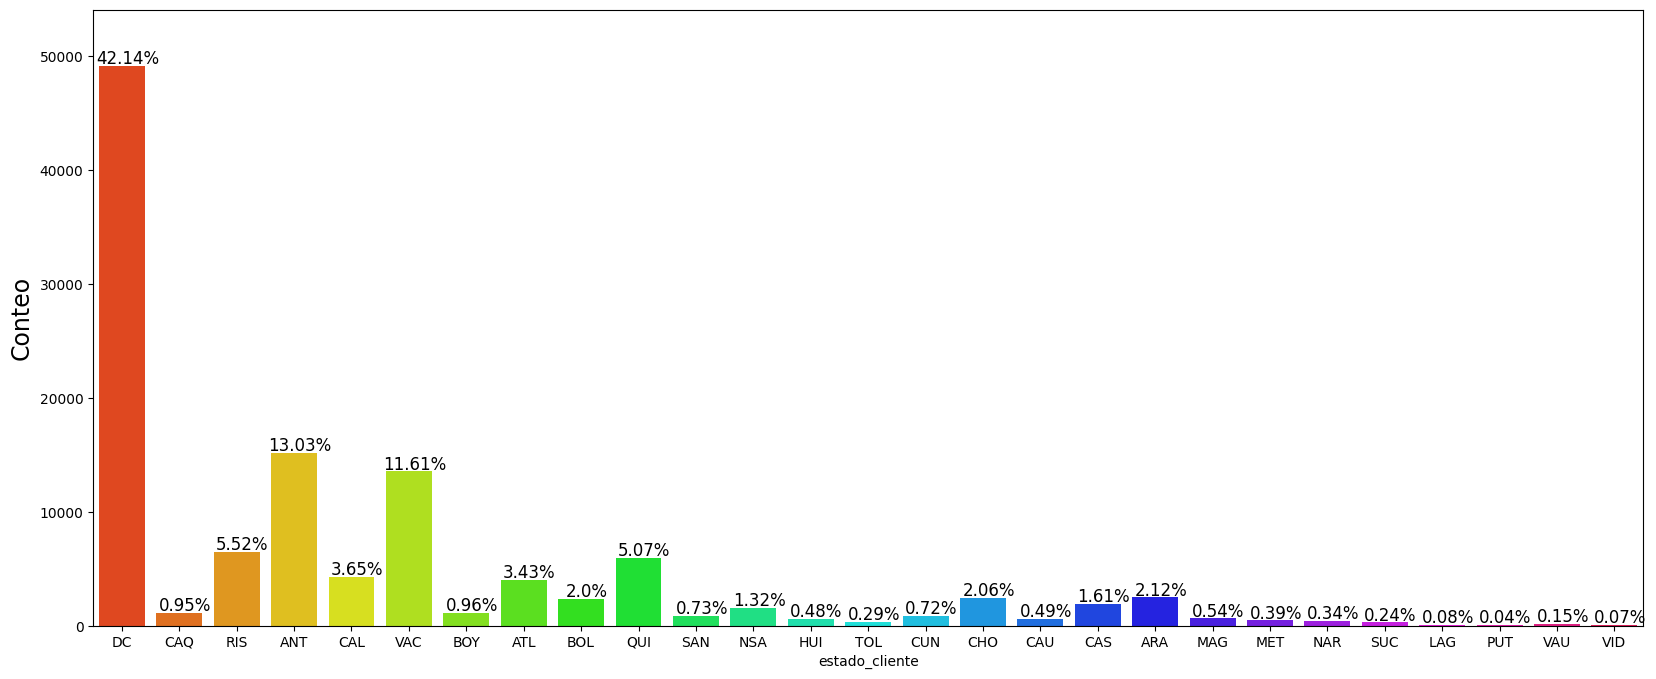

In [7]:
# de donde se realizaron mas pedidos
plot_porcentajes('estado_cliente', df)

<ipython-input-6-185fe0450eaa>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.countplot(x=estado, data=datos, orient='h', palette='hsv')


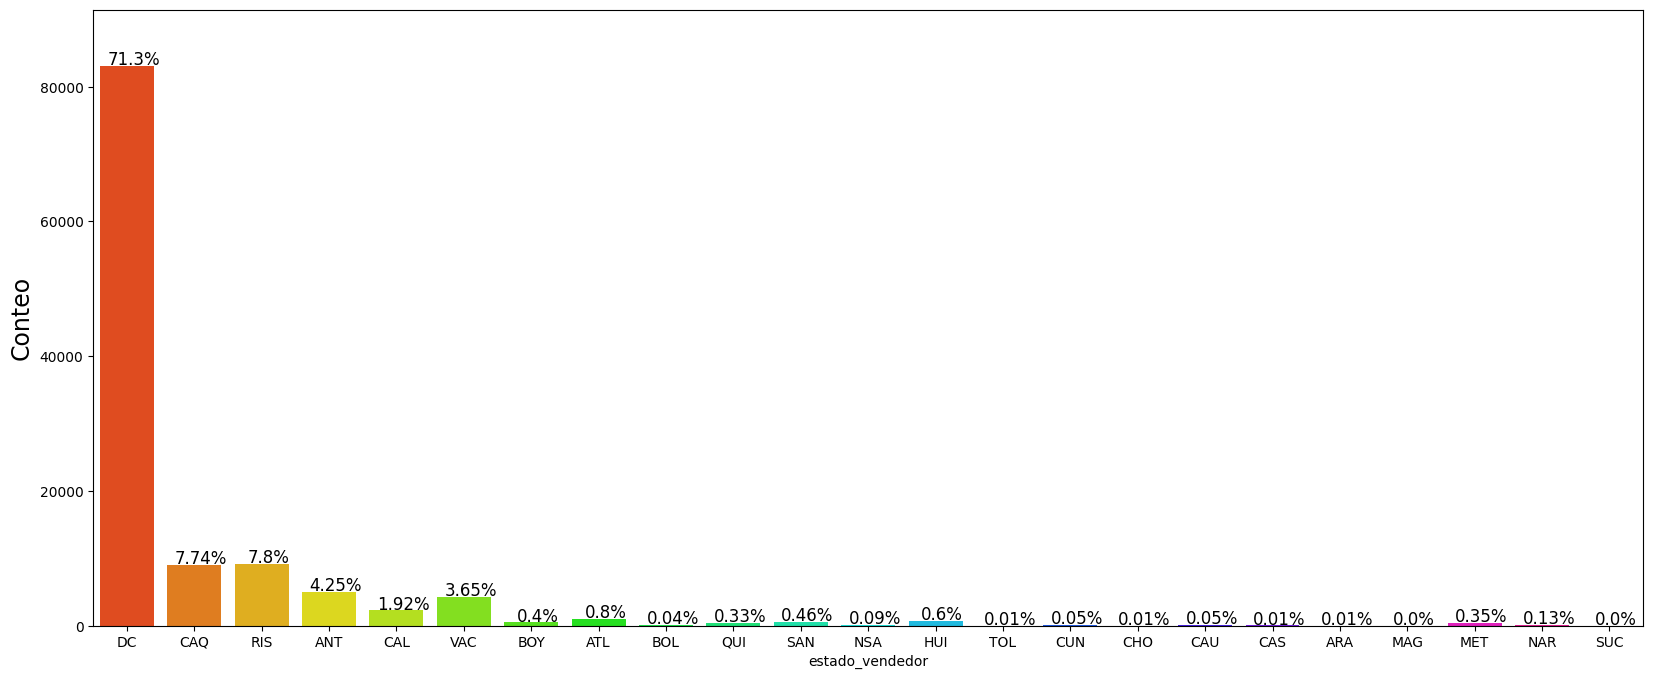

In [8]:
# departamento donde se cosentran mas vendedores
plot_porcentajes('estado_vendedor', df)

<ipython-input-6-185fe0450eaa>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.countplot(x=estado, data=datos, orient='h', palette='hsv')


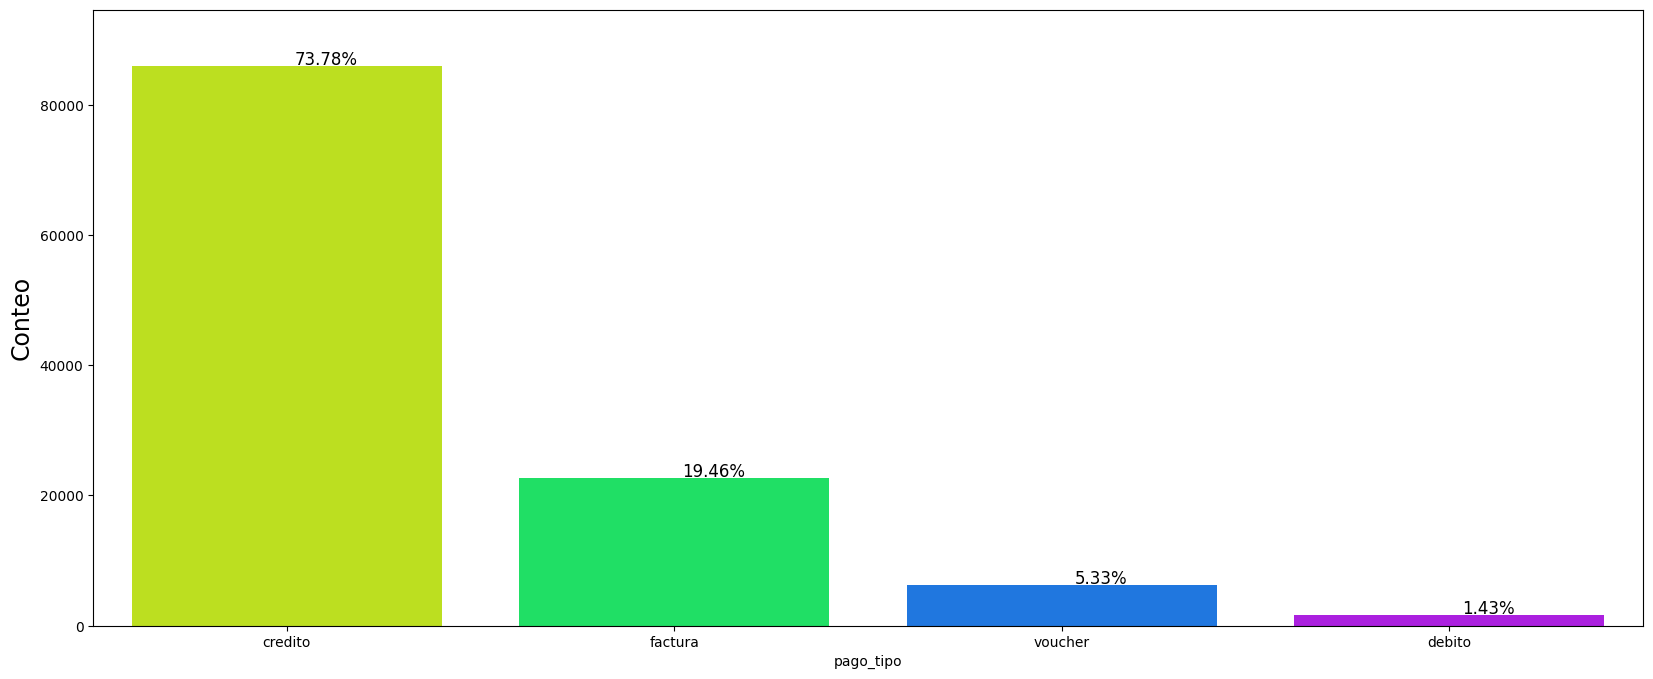

In [9]:
# metodo de pago mas comun
plot_porcentajes('pago_tipo', df)

## Aula 2

### 2.1 Modelo RFM


El modelo RFM (Recency, Frequency, Monetary) es una técnica de segmentación de clientes utilizada en marketing y gestión de clientes. Se basa en tres dimensiones principales para clasificar a los clientes en grupos homogéneos:

1. **Recency (Recencia):** Se refiere a la antigüedad de la última interacción del cliente con la empresa. Por lo general, se mide en términos de tiempo transcurrido desde la última compra, visita al sitio web o interacción en redes sociales.

2. **Frequency (Frecuencia):** Hace referencia a la frecuencia con la que un cliente realiza transacciones o interactúa con la empresa en un período de tiempo determinado. Puede medirse como el número total de transacciones en un período específico.

3. **Monetary (Monetario):** Se refiere al valor monetario total que un cliente ha aportado a la empresa en un período de tiempo determinado. Puede ser el total gastado en compras, ingresos generados, entre otros.

El modelo RFM se utiliza para identificar diferentes segmentos de clientes en función de su comportamiento de compra y su valor para la empresa. Estos segmentos suelen ser:

+ **Clientes de alto valor:** Aquellos que han realizado compras recientes, con frecuencia y que han generado ingresos significativos para la empresa.
+ **Clientes de bajo valor:** Aquellos que han realizado compras hace tiempo, con poca frecuencia y que han generado ingresos bajos para la empresa.
+ **Clientes en riesgo de perderse:** Aquellos que han realizado compras en el pasado pero han disminuido su frecuencia o valor en el tiempo.
+ **Nuevos clientes:** Aquellos que han realizado su primera compra recientemente y es importante fomentar su lealtad.

Al segmentar a los clientes en estos grupos, las empresas pueden personalizar sus estrategias de marketing, ventas y servicio al cliente para maximizar el valor de cada segmento y mejorar la retención de clientes.

#### **Recencia (R)**
##### ¿Hace cuántos días fue la última compra que realizó este cliente?

#### **Frecuencia (F)**
##### ¿Cuántas compras este cliente hizo en tu empresa, desde que se registró?

#### **Valor Monetario (M)**
##### ¿Cuánto dinero este cliente ya gastó en tu empresa?

In [10]:
# seleccionar la informacion del cliente del df original
df_olist = df[['id_unico_cliente', 'id_cliente', 'horario_pedido', 'item_id', 'precio']]
df_olist.head()

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99


In [11]:
# agrupando a los clientes por su id_unico_cliente y encontrando la fecha y hora
# del pedido más reciente (horario_pedido.max()) para cada cliente
df_compra = df.groupby('id_unico_cliente').horario_pedido.max().reset_index()
df_compra.columns = ['id_unico_cliente', 'fecha_max_compra']
df_compra['fecha_max_compra'] = pd.to_datetime(df_compra['fecha_max_compra'])
df_compra.head()

,id_unico_cliente,fecha_max_compra
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


En el modelo RFM, la recencia generalmente se refiere a la "edad" o "tiempo transcurrido desde la última interacción del cliente". Por lo tanto, calcular la recencia como la diferencia en días entre la fecha más reciente en el conjunto de datos y la fecha de compra de cada cliente es una forma común y válida de medir la recencia en el modelo RFM.
1. **df_compra['fecha_max_compra']:**
Selecciona la columna fecha_max_compra del DataFrame df_compra.

2. **df_compra['fecha_max_compra'].max():**
Obtiene el valor máximo de la columna fecha_max_compra, es decir, la fecha y hora más reciente de todas las compras más recientes de los clientes.

3. **df_compra['fecha_max_compra'].max() - df_compra['fecha_max_compra']:**
Resta cada valor de la columna fecha_max_compra del valor máximo obtenido en el paso anterior. El resultado de esta operación es una serie de diferencias de tiempo (timedeltas) entre la fecha más reciente y cada fecha en fecha_max_compra.

4. **(df_compra['fecha_max_compra'].max() - df_compra['fecha_max_compra']).dt.days:**
Convierte las diferencias de tiempo resultantes en días. La propiedad .dt.days extrae el componente de días de los objetos timedelta resultantes.

In [12]:
df_compra['resencia']= (df_compra['fecha_max_compra'].max() - df_compra['fecha_max_compra']).dt.days
df_compra.head()

,id_unico_cliente,fecha_max_compra,resencia
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,115
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,118
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,541
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,325
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,292


In [13]:
# unir dos df con columna en comun en df_usuario
df_usuario = pd.merge(df_olist, df_compra[['id_unico_cliente', 'resencia']], on='id_unico_cliente')
df_usuario.head()

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211


### 2.2 Regla del codo

Ahora, necesitamos usar el Método del Codo, la idea es ejecutar el algoritmo KMeans para varias cantidades diferentes de clusters y así poder determinar el número ideal de clusters.

A medida que aumentamos el número de clusters con KMeans, las diferencias entre los diversos clusters disminuyen y las diferencias por dentro de los clusters van aumentando. Entonces, debemos hallar un equilibrio de modo que las observaciones que conforman cada agrupación sean lo más homogéneas posible y que las diversas agrupaciones se puedan diferenciar entre sí.

### 2.3 Codificando la Regla del Codo


####**KMeans**
 es una clase en la biblioteca scikit-learn de Python que implementa el algoritmo de clustering KMeans. Este algoritmo es ampliamente utilizado para dividir un conjunto de datos en grupos (clusters) basados en similitudes de características. Cada grupo tiene un centroide que representa el "centro" del cluster, y los puntos de datos se asignan al cluster cuyo centroide es más cercano en términos de distancia euclidiana.

KMeans es útil para varios propósitos en análisis de datos y aprendizaje automático, como segmentación de clientes, comprensión de patrones en datos, compresión de imágenes y más. Algunas de las aplicaciones comunes incluyen:

+ **Segmentación de clientes:** Identificar grupos de clientes con comportamientos similares para personalizar estrategias de marketing.

+ **Agrupamiento de documentos:** Agrupar documentos por temas o contenido similar.

+ **Compresión de imágenes:** Reducir la cantidad de datos en una imagen manteniendo la calidad visual al agrupar píxeles similares.

+ **Análisis de redes sociales:** Identificar comunidades o grupos de usuarios con intereses similares en redes sociales.

En resumen, KMeans es una herramienta poderosa para explorar y comprender conjuntos de datos mediante la identificación de patrones subyacentes y la agrupación de datos en clusters significativos.

In [14]:
from sklearn.cluster import KMeans
'''La inercia en el contexto de clustering (en este caso, usando el algoritmo KMeans)
 representa la suma de las distancias al cuadrado de cada punto de datos al
 centroide de su cluster correspondiente. En otras palabras, la inercia mide cuán
 compactos y cercanos están los puntos dentro de cada cluster.
En el contexto del código que proporcionaste, donde se calcula la inercia para
 diferentes números de clusters, la inercia se utiliza como una métrica para
 evaluar la "bondad" de ajuste del modelo KMeans con respecto al número de clusters.
La idea es que a medida que aumentamos el número de clusters, la inercia tiende
 a disminuir, ya que los clusters son más pequeños y los puntos están más cerca
 de sus respectivos centroides. Sin embargo, hay un punto donde añadir más clusters
 ya no proporciona una mejora significativa en la inercia, lo que indica que hemos
 alcanzado un número adecuado de clusters para representar los datos de manera
 eficiente. Esto se puede identificar visualmente en un gráfico de la inercia
 en función del número de clusters, buscando el punto donde se observa un "codo" en la curva.
'''
def calcular_inercia(datos):
    ''' la función devuelve una lista con 10 valores de inercia, cada uno correspondiente
     a la inercia calculada para el modelo KMeans con un número de clusters que va de 1 a 10.
     Este proceso es útil para evaluar y visualizar la disminución de la inercia con el aumento
     del número de clusters, lo que puede ayudar a determinar el número óptimo de clusters
     utilizando el método del codo (elbow method).'''

    # Crear una lista para almacenar la inercia de cada número de clusters
    '''La inercia en KMeans se refiere a la suma de los cuadrados de las distancias
     de cada punto a su centroide más cercano, lo que da una medida de la compactación de los clusters.'''
    inercia = []
    # Iterar sobre un rango de 1 a 10 (inclusive) para probar diferentes números de clusters
    for k in range(1, 11):
        # Crear un modelo KMeans con el número de clusters actual y un estado aleatorio fijo para reproducibilidad
        kmeans = KMeans(n_clusters=k, random_state=42)
        # Ajustar el modelo KMeans a los datos
        kmeans.fit(X=datos)
        # Asignar las etiquetas de los clusters a los datos
        datos['cluster'] = kmeans.labels_
        # Calcular la inercia (suma de cuadrados intra-cluster) y añadirlo a la lista de inercia
        inercia.append(kmeans.inertia_)
    # Devolver la lista de inercia para cada número de clusters probado
    return inercia

In [15]:
df_resencia = df_usuario[['resencia']]
df_resencia.head()

,resencia
0,474
1,298
2,298
3,483
4,211


In [16]:
suma_cuadrados = calcular_inercia(df_resencia)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-14-80b566cdaf53>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos['cluster'] = kmeans.labels_
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
<ipython-input-14-80b566cdaf53>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

In [17]:
print(f'\ninercias {suma_cuadrados}')


inercias [2733029504.943269, 807902990.2831912, 362034954.49866545, 213835591.34403944, 135907975.91665876, 96309949.08373564, 69804675.35458721, 55561456.664346814, 44169644.89983238, 36139179.42322782]


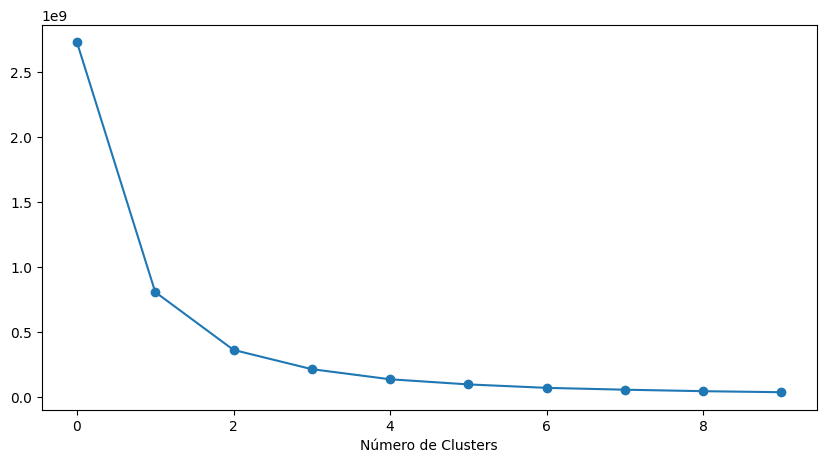

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(suma_cuadrados, marker='o')
plt.xlabel('Número de Clusters')
plt.show()

### 2.4 Regla Matemática

¿Cómo podemos identificar si el mejor número de clusters es 3, 4 o 5?

¡Existe una solución matemática!



> ![](https://miro.medium.com/max/2775/1*9J7Wnh5L0eIcHXBeWlzvNA.png)


Lo primero que debemos hacer, es definir una recta conectando el primer punto (cluster 1) al último punto (cluster 9).

En este caso, P0 es el punto del cluster 1 y P1 es el punto del cluster 9. El par (x,y) representa las coordenadas de cualquier punto desde el cual deseemos  calcular la distancia hasta la recta. Calculando todas las distancias, lograremos determinar el punto que indica el número ideal de clusters.

### 2.5 Codificando la Regla Matemática

+ x1, y1 = 2, inercia[0]: Asigna el valor 2 a x1 y el primer elemento de la lista inercia a y1.
+ x2, y2 = 20, inercia[-1]: Asigna el valor 20 a x2 y el último elemento de la lista inercia a y2.
+ distancias = []: Inicializa una lista vacía llamada distancias para almacenar las distancias calculadas.
+ for i in range(len(inercia)):: Itera sobre los índices de la lista inercia.
+ x0 = i + 2: Calcula el valor de x0 sumando i y 2.
+ y0 = inercia[i]: Asigna el valor del elemento en la posición i de la lista inercia a y0.
+ numerador = abs((y2 - y1)*x0 - (x2 - x1)*y0 + x2*y1 - y2*x1): Calcula el numerador de la distancia euclidiana entre el punto (x0, y0) y la recta que pasa por (x1, y1) y (x2, y2).
+ denominador = np.sqrt((y2 - y1)**2 + (x2 - x1)**2): Calcula el denominador de la distancia euclidiana.
+ distancias.append(numerador / denominador): Añade la distancia euclidiana calculada a la lista distancias.
+ return distancias.index(max(distancias)) + 2: Retorna el índice del valor máximo en la lista distancias más 2. Este valor corresponde al número ideal de clusters según el método de "codo" para encontrar el punto donde la inercia (variabilidad intra-cluster) comienza a disminuir de manera lineal.

In [19]:
def numero_idela_clusters(inercia):
    # Establecer los puntos inicial (x1, y1) y final (x2, y2) de la recta
    x1, y1 = 2, inercia[0]
    x2, y2 = 20, inercia[-1]

    # Inicializar una lista para almacenar las distancias
    distancias = []

    # Calcular la distancia de cada punto a la recta
    for i in range(len(inercia)):
        x0 = i + 2
        y0 = inercia[i]
        # formula
        numerador = abs((y2 - y1)*x0 - (x2 - x1)*y0 + x2*y1 - y2*x1)
        denominador = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distancias.append(numerador / denominador)

    # Encontrar el índice del valor máximo en las distancias
    # y sumar 2 para obtener el número ideal de clusters
    return distancias.index(max(distancias)) + 2

In [20]:
print(f'El numero idel de clusters es: {numero_idela_clusters(suma_cuadrados)}')

El numero idel de clusters es: 4


## Aula 3

### 3.1 Clusterizando la Recencia

In [21]:
# asignando la recencia a 4 clusters(grupos)
kmeans = KMeans(n_clusters=4, random_state=42)
df_usuario['resenca_cluster'] = kmeans.fit_predict(df_resencia)
df_usuario.head()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,resenca_cluster
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,1
1,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,1,112.99,298,2
2,9eae34bbd3a474ec5d07949ca7de67c0,8912fc0c3bbf1e2fbf35819e21706718,2017-11-09 00:50:13,2,112.99,298,2
3,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,1
4,23397e992b09769faf5e66f9e171a241,6bc8d08963a135220ed6c6d098831f84,2018-02-03 19:45:40,1,106.99,211,0


In [22]:
# agrupando por cluster buscando la media de la recencia
agripado_por_cluster = df_usuario.groupby('resenca_cluster')['resencia'].mean().reset_index()
agripado_por_cluster

,resenca_cluster,resencia
0,0,187.656789
1,1,490.622269
2,2,319.957296
3,3,66.790878


In [23]:
# ordenar los cluster de mayor a menor en en base a la media de la recencia
agrupado_por_cluster_ordenado = agripado_por_cluster.sort_values(by='resencia', ascending=False).reset_index(drop=True)
agrupado_por_cluster_ordenado

,resenca_cluster,resencia
0,1,490.622269
1,2,319.957296
2,0,187.656789
3,3,66.790878


In [24]:
# crear nueva columna en df (indice) con los valores del index
# esto se hace con el fin de reorganisar la asignacion de cluster
# queremos que la recencia mas baja quede en cluster mas altao
agrupado_por_cluster_ordenado['indice'] = agrupado_por_cluster_ordenado.index
agrupado_por_cluster_ordenado

,resenca_cluster,resencia,indice
0,1,490.622269,0
1,2,319.957296,1
2,0,187.656789,2
3,3,66.790878,3


In [25]:
# juntamos los df df_usuario, agrupado_por_cluster_ordenado
juntando_cluster = pd.merge(df_usuario, agrupado_por_cluster_ordenado[['resenca_cluster', 'indice']],
                            on='resenca_cluster')
juntando_cluster.head()

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,resenca_cluster,indice
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,1,0
1,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,1,0
2,567ab47ca4deb92d46dbf54dce07d0a7,fd3a0b1bd209f0e7d420c9c3d1127613,2017-03-23 15:10:17,1,126.99,528,1,0
3,f40ab89b622248b7ca125af4b486b887,fbd40c083aa8cddebb5265b2ba6aaf2e,2017-05-16 10:00:49,1,124.99,474,1,0
4,749943913a9851a39c9baf51877fbab6,10558ef4afea173bfb5e2cbe3d5b0bb5,2017-03-18 23:04:36,1,126.99,533,1,0


In [26]:
# eliminamos la columna resenca_cluster	ya que ahora el indice es nuestro cluster ordenado
removiendo_datos = juntando_cluster.drop(['resenca_cluster'], axis=1)
removiendo_datos.head()

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,indice
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0
1,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0
2,567ab47ca4deb92d46dbf54dce07d0a7,fd3a0b1bd209f0e7d420c9c3d1127613,2017-03-23 15:10:17,1,126.99,528,0
3,f40ab89b622248b7ca125af4b486b887,fbd40c083aa8cddebb5265b2ba6aaf2e,2017-05-16 10:00:49,1,124.99,474,0
4,749943913a9851a39c9baf51877fbab6,10558ef4afea173bfb5e2cbe3d5b0bb5,2017-03-18 23:04:36,1,126.99,533,0


In [27]:
# renombramos la columna indice con resencia_cluster
df_final = removiendo_datos.rename(columns={'indice': 'resencia_cluster'})
df_final.head()

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,resencia_cluster
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0
1,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0
2,567ab47ca4deb92d46dbf54dce07d0a7,fd3a0b1bd209f0e7d420c9c3d1127613,2017-03-23 15:10:17,1,126.99,528,0
3,f40ab89b622248b7ca125af4b486b887,fbd40c083aa8cddebb5265b2ba6aaf2e,2017-05-16 10:00:49,1,124.99,474,0
4,749943913a9851a39c9baf51877fbab6,10558ef4afea173bfb5e2cbe3d5b0bb5,2017-03-18 23:04:36,1,126.99,533,0


In [28]:
df_final.sample(5)

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,resencia_cluster
49376,0de97ff655abfc142ba6fc83e86bf082,08dc68ad9ab343289844fa36f6963b8f,2017-12-02 18:26:35,1,2700.0,274,1
90419,f5136b8fc0ca2d9037d400ec1f196305,c42188ecda96aa87f2f7ae67974093ab,2018-05-11 07:12:30,1,24.9,115,3
32303,6d18d93feaf5a91d029a1ca3ea0a7313,e84e1c70c5abcab689d6bcee4023a083,2017-11-25 10:13:51,1,23.4,281,1
33334,76452dccd38534f1cd8b0c0245c57b76,d859e804a8ba7158f12531184d18921e,2017-10-16 12:26:34,1,349.9,321,1
54726,d92087333b9c4afb7f6ec9d1258e2ea3,fbf5039b1d330e60055aa9f3969d3434,2018-02-01 00:33:25,1,196.2,214,2


In [29]:
'''esta funcion hace exactamente todo lo anterior
cluster_actual -> clouster para cada clasificacion del modelo RFM
    Recencia, frecuencia, moonetario.
target -> Recencia, frecuencia, moonetario.
df -> dataFrame donde se encirntar las columnas cluster_actual, target.
asc -> booleano para ordenar de forma ascendente o descendente
 '''
def ordenador_cluster(cluster_actual, target, df, asc=False):
    # Agrupar por el cluster actual y calcular la media del target
    agrupado_por_cluster = df.groupby(cluster_actual)[target].mean().reset_index()

    # Ordenar los clusters basados en la media del target
    agrupado_por_cluster_ordenado = agrupado_por_cluster.sort_values(by=target, ascending=asc).reset_index(drop=True)

    # Agregar un índice a los clusters ordenados
    agrupado_por_cluster_ordenado['indice'] = agrupado_por_cluster_ordenado.index

    # Combinar el dataframe original con el dataframe de clusters ordenados
    juntando_cluster = pd.merge(df, agrupado_por_cluster_ordenado[[cluster_actual, 'indice']], on=cluster_actual)

    # Eliminar la columna del cluster original
    removiendo_datos = juntando_cluster.drop([cluster_actual], axis=1)

    # Renombrar la columna de índice como el cluster actual
    df_final = removiendo_datos.rename(columns={'indice': cluster_actual})

    return df_final

In [30]:
# utilizar la funcion para la recencia
df_usuario = ordenador_cluster('resenca_cluster', 'resencia', df_usuario)
df_usuario.head()

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,resenca_cluster
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0
1,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0
2,567ab47ca4deb92d46dbf54dce07d0a7,fd3a0b1bd209f0e7d420c9c3d1127613,2017-03-23 15:10:17,1,126.99,528,0
3,f40ab89b622248b7ca125af4b486b887,fbd40c083aa8cddebb5265b2ba6aaf2e,2017-05-16 10:00:49,1,124.99,474,0
4,749943913a9851a39c9baf51877fbab6,10558ef4afea173bfb5e2cbe3d5b0bb5,2017-03-18 23:04:36,1,126.99,533,0


In [31]:
# ver como se ordena la media de la recencia agrupada por la columan resenca_cluster
df_usuario.groupby('resenca_cluster')['resencia'].describe()

,count,mean,std,min,25%,50%,75%,max
resenca_cluster,,,,,,,,
0,20324.0,490.622269,59.293154,406.0,444.0,481.0,533.0,728.0
1,30957.0,319.957296,44.086874,254.0,281.0,313.0,357.0,405.0
2,33510.0,187.656789,34.961732,128.0,158.0,187.0,218.0,253.0
3,31790.0,66.790878,36.009443,0.0,33.0,67.0,100.0,127.0


### 3.2 Clusterizando la Frecuencia

In [32]:
# obtener la frecuancia de compra de los clientes
'''agrupamos por id_unico_cliente buscando contar la cantidad de pedidos realizados
por cada cliente y lo guardamos en df_frrecuencia'''
df_frrecuencia = df.groupby('id_unico_cliente').pedido_aprobado.count().reset_index()
df_frrecuencia.columns = ['id_unico_cliente', 'frecuencia']
df_frrecuencia.head()

,id_unico_cliente,frecuencia
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [33]:
# juntamos los df df_usuario, df_frrecuencia
df_usuario = pd.merge(df_usuario, df_frrecuencia, on='id_unico_cliente')
df_usuario.head()

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,resenca_cluster,frecuencia
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0,1
1,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0,1
2,567ab47ca4deb92d46dbf54dce07d0a7,fd3a0b1bd209f0e7d420c9c3d1127613,2017-03-23 15:10:17,1,126.99,528,0,1
3,f40ab89b622248b7ca125af4b486b887,fbd40c083aa8cddebb5265b2ba6aaf2e,2017-05-16 10:00:49,1,124.99,474,0,1
4,749943913a9851a39c9baf51877fbab6,10558ef4afea173bfb5e2cbe3d5b0bb5,2017-03-18 23:04:36,1,126.99,533,0,1


In [34]:
# asignar la frecuencia a 4 clusters
df_frecuencia = df_usuario[['frecuencia']]
kmeans = KMeans(n_clusters=4, random_state=42)
df_usuario['frecuencia_cluster'] = kmeans.fit_predict(df_frecuencia)
df_usuario.head()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,resenca_cluster,frecuencia,frecuencia_cluster
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0,1,0
1,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0,1,0
2,567ab47ca4deb92d46dbf54dce07d0a7,fd3a0b1bd209f0e7d420c9c3d1127613,2017-03-23 15:10:17,1,126.99,528,0,1,0
3,f40ab89b622248b7ca125af4b486b887,fbd40c083aa8cddebb5265b2ba6aaf2e,2017-05-16 10:00:49,1,124.99,474,0,1,0
4,749943913a9851a39c9baf51877fbab6,10558ef4afea173bfb5e2cbe3d5b0bb5,2017-03-18 23:04:36,1,126.99,533,0,1,0


In [35]:
# ver como se ordena la frecuencia agrupada por la columan frecuencia_cluster
df_usuario.groupby('frecuencia_cluster')['frecuencia'].describe()

,count,mean,std,min,25%,50%,75%,max
frecuencia_cluster,,,,,,,,
0,106570.0,1.306343,0.570539,0.0,1.0,1.0,2.0,3.0
1,514.0,24.447471,5.669776,16.0,20.0,24.0,24.0,38.0
2,9422.0,5.848015,2.496369,4.0,4.0,5.0,6.0,15.0
3,75.0,75.000000,0.000000,75.0,75.0,75.0,75.0,75.0


In [36]:
# ordenar los cluster para la frecuencia
# queremos que a mayor frecuencia mayor sea la asignacion del cluster
df_usuario = ordenador_cluster('frecuencia_cluster', 'frecuencia', df_usuario, asc=True)

In [37]:
# ver como se ordena la frecuencia agrupada por la columan frecuencia_cluster
df_usuario.groupby('frecuencia_cluster')['frecuencia'].describe()

,count,mean,std,min,25%,50%,75%,max
frecuencia_cluster,,,,,,,,
0,106570.0,1.306343,0.570539,0.0,1.0,1.0,2.0,3.0
1,9422.0,5.848015,2.496369,4.0,4.0,5.0,6.0,15.0
2,514.0,24.447471,5.669776,16.0,20.0,24.0,24.0,38.0
3,75.0,75.000000,0.000000,75.0,75.0,75.0,75.0,75.0


### 3.3 Clusterizando el Valor Monetario (Ingresos)

In [38]:
# sumar los gastos totales de cada cliente
df_ingresos = df.groupby('id_unico_cliente').pago_valor.sum().reset_index()
df_ingresos.columns = ['id_unico_cliente', 'ingresos']
df_usuario = pd.merge(df_usuario, df_ingresos, on='id_unico_cliente')
df_usuario.head()

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,resenca_cluster,frecuencia,frecuencia_cluster,ingresos
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0,1,0,146.87
1,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0,1,0,140.61
2,567ab47ca4deb92d46dbf54dce07d0a7,fd3a0b1bd209f0e7d420c9c3d1127613,2017-03-23 15:10:17,1,126.99,528,0,1,0,142.05
3,f40ab89b622248b7ca125af4b486b887,fbd40c083aa8cddebb5265b2ba6aaf2e,2017-05-16 10:00:49,1,124.99,474,0,1,0,155.70
4,749943913a9851a39c9baf51877fbab6,10558ef4afea173bfb5e2cbe3d5b0bb5,2017-03-18 23:04:36,1,126.99,533,0,1,0,148.33


In [39]:
df_pago = df_usuario[['ingresos']]
df_pago.head()

,ingresos
0,146.87
1,140.61
2,142.05
3,155.70
4,148.33


In [40]:
# agrupar los gastos en 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df_usuario['ingresos_cluster'] = kmeans.fit_predict(df_pago)
df_usuario.head()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,resenca_cluster,frecuencia,frecuencia_cluster,ingresos,ingresos_cluster
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0,1,0,146.87,0
1,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0,1,0,140.61,0
2,567ab47ca4deb92d46dbf54dce07d0a7,fd3a0b1bd209f0e7d420c9c3d1127613,2017-03-23 15:10:17,1,126.99,528,0,1,0,142.05,0
3,f40ab89b622248b7ca125af4b486b887,fbd40c083aa8cddebb5265b2ba6aaf2e,2017-05-16 10:00:49,1,124.99,474,0,1,0,155.70,0
4,749943913a9851a39c9baf51877fbab6,10558ef4afea173bfb5e2cbe3d5b0bb5,2017-03-18 23:04:36,1,126.99,533,0,1,0,148.33,0


In [41]:
# ordenar los cluster para el valor monetario
# queremos que a mayor valor monetario gastado mayor sea la asignacion del cluster
df_usuario = ordenador_cluster('ingresos_cluster', 'ingresos', df_usuario, asc=True)

In [42]:
df_usuario.groupby('ingresos_cluster')['ingresos'].describe()

,count,mean,std,min,25%,50%,75%,max
ingresos_cluster,,,,,,,,
0,114904.0,261.485763,377.283592,9.59,69.90,132.82,270.00,3080.96
1,1478.0,5900.843911,2894.129234,3083.40,3798.75,4875.25,7315.92,16313.60
2,191.0,27358.656911,10032.832924,17069.76,19167.26,25051.89,30186.00,45256.00
3,8.0,109312.640000,0.000000,109312.64,109312.64,109312.64,109312.64,109312.64


## Aula 4

### 4.1 Creando la puntuación

In [43]:
df_usuario.head()

,id_unico_cliente,id_cliente,horario_pedido,item_id,precio,resencia,resenca_cluster,frecuencia,frecuencia_cluster,ingresos,ingresos_cluster
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,2017-05-16 15:05:35,1,124.99,474,0,1,0,146.87,0
1,3c799d181c34d51f6d44bbbc563024db,f0ac8e5a239118859b1734e1087cbb1f,2017-05-07 20:11:26,1,124.99,483,0,1,0,140.61,0
2,567ab47ca4deb92d46dbf54dce07d0a7,fd3a0b1bd209f0e7d420c9c3d1127613,2017-03-23 15:10:17,1,126.99,528,0,1,0,142.05,0
3,f40ab89b622248b7ca125af4b486b887,fbd40c083aa8cddebb5265b2ba6aaf2e,2017-05-16 10:00:49,1,124.99,474,0,1,0,155.70,0
4,749943913a9851a39c9baf51877fbab6,10558ef4afea173bfb5e2cbe3d5b0bb5,2017-03-18 23:04:36,1,126.99,533,0,1,0,148.33,0


In [44]:
# sacamos las columnas que nos interesan en un df (df_final)
df_final = df_usuario[['id_unico_cliente', 'resencia', 'resenca_cluster', 'frecuencia', 'frecuencia_cluster', 'ingresos', 'ingresos_cluster']]
df_final.tail()

,id_unico_cliente,resencia,resenca_cluster,frecuencia,frecuencia_cluster,ingresos,ingresos_cluster
116576,0a0a92112bd4c708ca5fde585afaa872,338,1,8,1,109312.64,3
116577,0a0a92112bd4c708ca5fde585afaa872,338,1,8,1,109312.64,3
116578,0a0a92112bd4c708ca5fde585afaa872,338,1,8,1,109312.64,3
116579,0a0a92112bd4c708ca5fde585afaa872,338,1,8,1,109312.64,3
116580,0a0a92112bd4c708ca5fde585afaa872,338,1,8,1,109312.64,3


In [45]:
# asignamos puntos a los clientes con base en los clusters del modelo RFM
'''maximo de puntos posibles 9, entre mas puntos tenga el cliente mejor sera categorizado'''
df_final['puntuacion'] = df_final['resenca_cluster'] + df_final['frecuencia_cluster'] + df_final['ingresos_cluster']
df_final.sample(5)

<ipython-input-45-de3a79f44e10>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['puntuacion'] = df_final['resenca_cluster'] + df_final['frecuencia_cluster'] + df_final['ingresos_cluster']


,id_unico_cliente,resencia,resenca_cluster,frecuencia,frecuencia_cluster,ingresos,ingresos_cluster,puntuacion
110801,a176838867d89ed62981cdf02b7ca3e1,182,2,4,1,922.16,0,3
61122,dc84254000d4346cb5920da6c3c4a574,195,2,1,0,90.55,0,2
46403,4e2270e45010f34f7308e7fd0ba18b48,304,1,1,0,97.04,0,1
112676,c5cc0bee4b73138ed973a1720df085aa,16,3,6,1,57.48,0,4
74783,252a5a7461ae95e4af38d293cbc4080e,222,2,2,0,223.40,0,2


In [46]:
# maximo de puntos en el df
df_final.puntuacion.max()

7

In [47]:
# nueva columna para segmentar los clientes
# clientes con 0 puntos seran inactivos
df_final['segmento']='inactivo'

# asignado segmentos a los clientes segun sus puntos
df_final.loc[df_final['puntuacion']>=1, 'segmento']='bussines'
df_final.loc[df_final['puntuacion']>=3, 'segmento']='master'
df_final.loc[df_final['puntuacion']>=5, 'segmento']='premiun'

<ipython-input-47-b5ed0a5f7e50>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['segmento']='inactivo'


In [48]:
# conatr la cantidad de clientes en cada segmento
df_final.segmento.value_counts()

segmento
bussines    63007
master      34624
inactivo    18361
premiun       589
Name: count, dtype: int64

In [49]:
df_final.head()

,id_unico_cliente,resencia,resenca_cluster,frecuencia,frecuencia_cluster,ingresos,ingresos_cluster,puntuacion,segmento
0,861eff4711a542e4b93843c6dd7febb0,474,0,1,0,146.87,0,0,inactivo
1,3c799d181c34d51f6d44bbbc563024db,483,0,1,0,140.61,0,0,inactivo
2,567ab47ca4deb92d46dbf54dce07d0a7,528,0,1,0,142.05,0,0,inactivo
3,f40ab89b622248b7ca125af4b486b887,474,0,1,0,155.70,0,0,inactivo
4,749943913a9851a39c9baf51877fbab6,533,0,1,0,148.33,0,0,inactivo


In [50]:
# exportar df
df_final.to_csv('/content/drive/MyDrive/Data_Science/Bootcamp Data Science/Machine Learning - Bootcamp DS3/Clusterización de datos: segmentación de clientes/RFM.csv', index=False)

### 4.2 Análisis visual de los resultados

In [51]:
def plot_segmento(x, y, datos):
    plt.figure(figsize=(10, 6))

    sns.set(palette='muted', color_codes=True, style='whitegrid')
    sns.scatterplot(x=x, y=y, data=datos, hue='segmento',
                    size='segmento', sizes=(50, 150),
                    size_order=['premiun', 'master', 'bussines', 'inactivo'])
    plt.show()


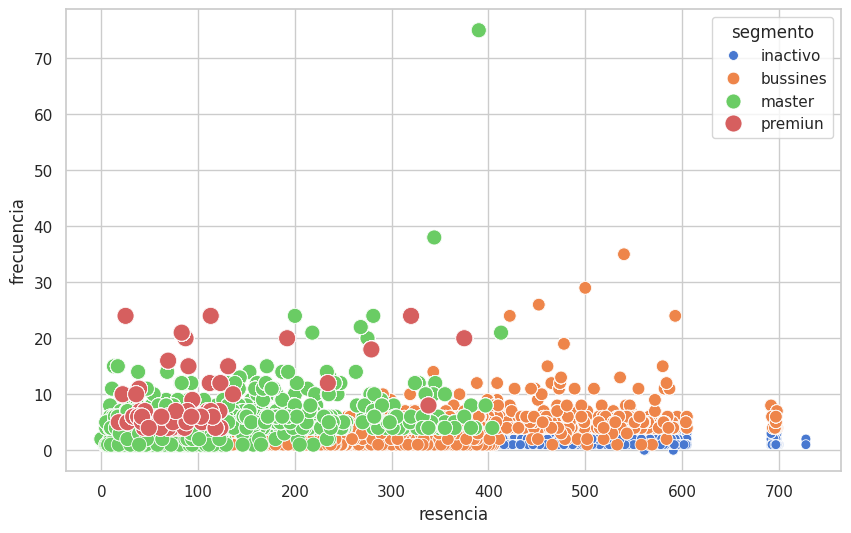

In [52]:
plot_segmento('resencia', 'frecuencia', df_final)

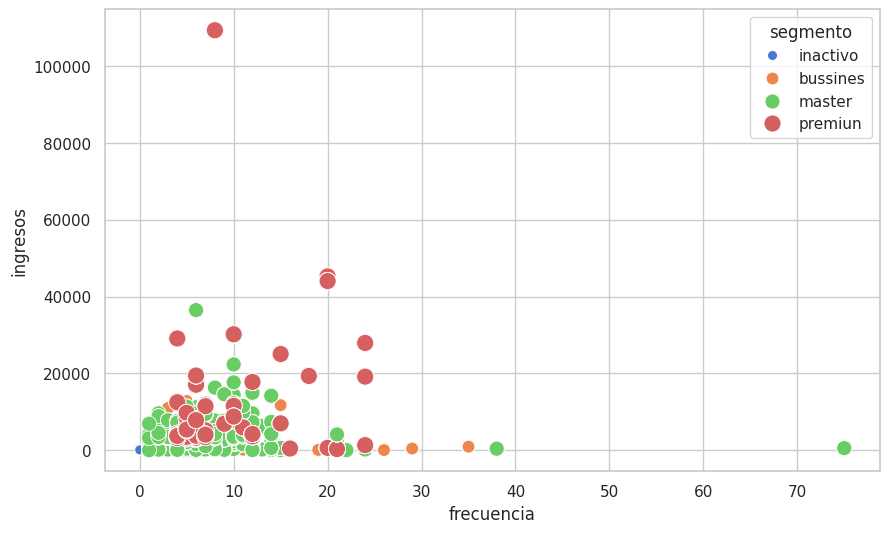

In [53]:
plot_segmento('frecuencia', 'ingresos', df_final)

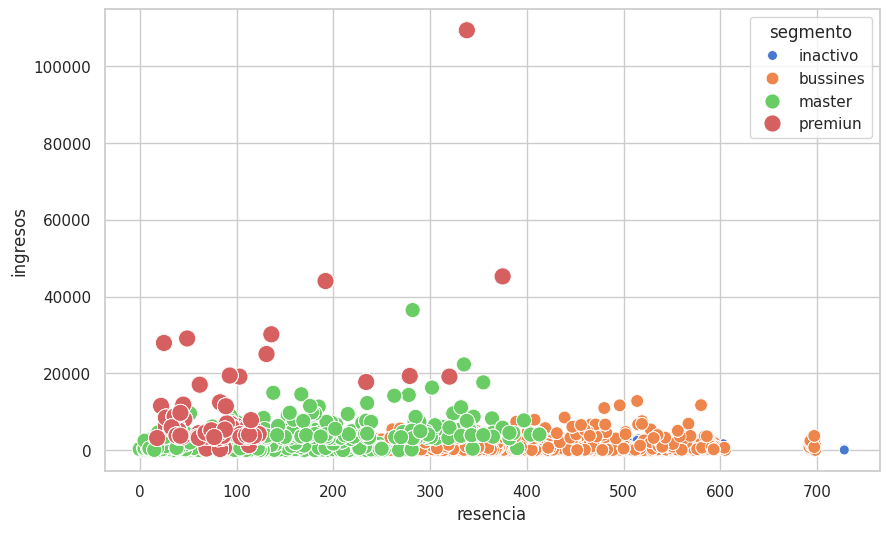

In [54]:
plot_segmento('resencia', 'ingresos', df_final)

<Axes: xlabel='count', ylabel='segmento'>

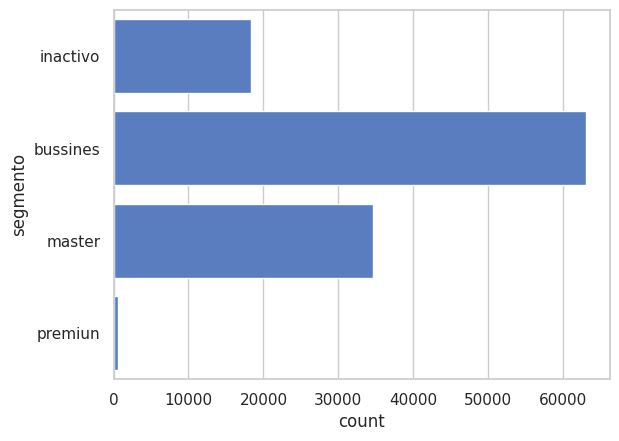

In [55]:
sns.countplot(df_final['segmento'])